<a href="https://colab.research.google.com/github/rezar362/Portfolio/blob/main/earnings_mood/earnings_mood.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Block 2: Extract acoustic features from each earnings call audio.
# Features: pitch (F0), energy, speech rate, pause ratio, MFCCs, ZCR.
# Segments audio into 30-second windows for time-series analysis.

import librosa
import numpy as np
import pandas as pd
import pickle
import os

DRIVE_PATH = '/content/drive/MyDrive/earnings_mood'
AUDIO_DIR  = f'{DRIVE_PATH}/audio'
FEATURES_FILE = f'{DRIVE_PATH}/acoustic_features.pkl'

COMPANIES = {
    'AAPL' : {'name': 'Apple',   'date': '2025-10-30'},
    'META' : {'name': 'Meta',    'date': '2025-10-29'},
    'GOOGL': {'name': 'Alphabet','date': '2026-02-04'},
    'AMZN' : {'name': 'Amazon',  'date': '2025-10-31'},
    'NFLX' : {'name': 'Netflix', 'date': '2026-01-21'},
}

SEGMENT_SEC = 30  # analyze in 30-second windows

def extract_features(audio_path, sr=22050, segment_sec=30):
    """Extract acoustic features per 30-second segment."""
    print(f"   Loading audio...")
    y, sr = librosa.load(audio_path, sr=sr, duration=300)  # max 5 minutes

    total_duration = len(y) / sr
    segment_len    = segment_sec * sr
    n_segments     = int(total_duration // segment_sec)

    print(f"   Duration: {total_duration:.0f}s | Segments: {n_segments}")

    segments = []
    for i in range(n_segments):
        start = i * segment_len
        end   = start + segment_len
        seg   = y[int(start):int(end)]

        # ── Pitch (F0) ───────────────────────────────────────
        f0, voiced_flag, _ = librosa.pyin(
            seg, fmin=50, fmax=400,
            sr=sr, fill_na=0.0
        )
        mean_pitch  = np.nanmean(f0[f0 > 0]) if np.any(f0 > 0) else 0
        pitch_var   = np.nanstd(f0[f0 > 0])  if np.any(f0 > 0) else 0
        voiced_ratio = np.mean(voiced_flag)

        # ── Energy (RMS) ──────────────────────────────────────
        rms        = librosa.feature.rms(y=seg)[0]
        mean_energy = np.mean(rms)
        energy_var  = np.std(rms)

        # ── Zero Crossing Rate (speech rate proxy) ───────────
        zcr        = librosa.feature.zero_crossing_rate(seg)[0]
        mean_zcr   = np.mean(zcr)

        # ── MFCCs (timbre/vocal quality) ──────────────────────
        mfccs      = librosa.feature.mfcc(y=seg, sr=sr, n_mfcc=13)
        mfcc_means = np.mean(mfccs, axis=1)
        mfcc_vars  = np.std(mfccs, axis=1)

        # ── Pause ratio ───────────────────────────────────────
        silence_threshold = 0.01
        pause_ratio = np.mean(rms < silence_threshold)

        # ── Spectral features ─────────────────────────────────
        spectral_centroid = np.mean(librosa.feature.spectral_centroid(y=seg, sr=sr))
        spectral_rolloff  = np.mean(librosa.feature.spectral_rolloff(y=seg, sr=sr))

        segment_features = {
            'segment'          : i,
            'timestamp'        : i * segment_sec,
            'mean_pitch'       : mean_pitch,
            'pitch_variance'   : pitch_var,
            'voiced_ratio'     : voiced_ratio,
            'mean_energy'      : mean_energy,
            'energy_variance'  : energy_var,
            'mean_zcr'         : mean_zcr,
            'pause_ratio'      : pause_ratio,
            'spectral_centroid': spectral_centroid,
            'spectral_rolloff' : spectral_rolloff,
        }

        # Add MFCCs
        for j, (m, v) in enumerate(zip(mfcc_means, mfcc_vars)):
            segment_features[f'mfcc_{j}_mean'] = m
            segment_features[f'mfcc_{j}_var']  = v

        segments.append(segment_features)

    return pd.DataFrame(segments)

# ── Process all companies ──────────────────────────────────────
all_features = {}

print("── Extracting acoustic features ──\n")
for ticker, info in COMPANIES.items():
    audio_path = f"{AUDIO_DIR}/{ticker}.wav"
    if not os.path.exists(audio_path):
        print(f"   {ticker} ✗ audio not found")
        continue

    print(f"── {ticker} ({info['name']}) ──")
    df_feat = extract_features(audio_path)
    df_feat['ticker'] = ticker
    df_feat['company'] = info['name']
    all_features[ticker] = df_feat
    print(f"   ✅ {len(df_feat)} segments extracted")
    print(f"   Mean pitch    : {df_feat['mean_pitch'].mean():.1f} Hz")
    print(f"   Mean energy   : {df_feat['mean_energy'].mean():.4f}")
    print(f"   Pause ratio   : {df_feat['pause_ratio'].mean():.2%}")
    print()

# ── Save features ──────────────────────────────────────────────
with open(FEATURES_FILE, 'wb') as f:
    pickle.dump(all_features, f)

print(f"✅ Features saved to Drive")
print("✅ Block 2 complete")

── Extracting acoustic features ──

── AAPL (Apple) ──
   Loading audio...
   Duration: 300s | Segments: 9
   ✅ 9 segments extracted
   Mean pitch    : 175.5 Hz
   Mean energy   : 0.0758
   Pause ratio   : 20.10%

── META (Meta) ──
   Loading audio...
   Duration: 300s | Segments: 9
   ✅ 9 segments extracted
   Mean pitch    : 31.3 Hz
   Mean energy   : 0.0000
   Pause ratio   : 99.96%

── GOOGL (Alphabet) ──
   Loading audio...
   Duration: 300s | Segments: 9
   ✅ 9 segments extracted
   Mean pitch    : 136.6 Hz
   Mean energy   : 0.0526
   Pause ratio   : 21.04%

── AMZN (Amazon) ──
   Loading audio...
   Duration: 300s | Segments: 9
   ✅ 9 segments extracted
   Mean pitch    : 118.8 Hz
   Mean energy   : 0.0689
   Pause ratio   : 11.62%

── NFLX (Netflix) ──
   Loading audio...
   Duration: 300s | Segments: 9
   ✅ 9 segments extracted
   Mean pitch    : 114.0 Hz
   Mean energy   : 0.0170
   Pause ratio   : 40.00%

✅ Features saved to Drive
✅ Block 2 complete


In [3]:
import os

AUDIO_DIR = '/content/drive/MyDrive/earnings_mood/audio'

# Delete bad META file and re-download with correct URL
meta_file = f"{AUDIO_DIR}/META.wav"
if os.path.exists(meta_file):
    os.remove(meta_file)
    print("✅ Deleted bad META file")

META_URL = "https://www.youtube.com/watch?v=GybsPjEO5_k"
print("⬇️  Downloading correct META Q4 2025 earnings call...")

!yt-dlp -f "bestaudio" \
    --extract-audio \
    --audio-format wav \
    --postprocessor-args "-t 300" \
    -o "{meta_file}" \
    "{META_URL}" \
    --quiet

if os.path.exists(meta_file):
    size = os.path.getsize(meta_file) / 1024 / 1024
    print(f"✅ META downloaded: {size:.1f} MB")
else:
    print("✗ Download failed")

✅ Deleted bad META file
⬇️  Downloading correct META Q4 2025 earnings call...
✅ META downloaded: 54.9 MB


In [4]:
import librosa
import numpy as np

y, sr = librosa.load('/content/drive/MyDrive/earnings_mood/audio/META.wav', sr=22050, duration=30)
rms = np.sqrt(np.mean(y**2))
print(f"META RMS: {rms:.4f} | Max: {np.max(np.abs(y)):.4f}")

META RMS: 0.0674 | Max: 0.6962


In [5]:
import librosa
import numpy as np
import pandas as pd
import pickle

DRIVE_PATH    = '/content/drive/MyDrive/earnings_mood'
AUDIO_DIR     = f'{DRIVE_PATH}/audio'
FEATURES_FILE = f'{DRIVE_PATH}/acoustic_features.pkl'

# Load existing features
with open(FEATURES_FILE, 'rb') as f:
    all_features = pickle.load(f)

# Re-extract META only
def extract_features(audio_path, sr=22050, segment_sec=30):
    y, sr = librosa.load(audio_path, sr=sr, duration=300)
    total_duration = len(y) / sr
    segment_len    = segment_sec * sr
    n_segments     = int(total_duration // segment_sec)
    segments = []
    for i in range(n_segments):
        start = i * segment_len
        end   = start + segment_len
        seg   = y[int(start):int(end)]
        f0, voiced_flag, _ = librosa.pyin(seg, fmin=50, fmax=400, sr=sr, fill_na=0.0)
        mean_pitch   = np.nanmean(f0[f0 > 0]) if np.any(f0 > 0) else 0
        pitch_var    = np.nanstd(f0[f0 > 0])  if np.any(f0 > 0) else 0
        voiced_ratio = np.mean(voiced_flag)
        rms          = librosa.feature.rms(y=seg)[0]
        mean_energy  = np.mean(rms)
        energy_var   = np.std(rms)
        zcr          = librosa.feature.zero_crossing_rate(seg)[0]
        mean_zcr     = np.mean(zcr)
        mfccs        = librosa.feature.mfcc(y=seg, sr=sr, n_mfcc=13)
        mfcc_means   = np.mean(mfccs, axis=1)
        mfcc_vars    = np.std(mfccs, axis=1)
        pause_ratio  = np.mean(rms < 0.01)
        spectral_centroid = np.mean(librosa.feature.spectral_centroid(y=seg, sr=sr))
        spectral_rolloff  = np.mean(librosa.feature.spectral_rolloff(y=seg, sr=sr))
        feat = {
            'segment': i, 'timestamp': i * segment_sec,
            'mean_pitch': mean_pitch, 'pitch_variance': pitch_var,
            'voiced_ratio': voiced_ratio, 'mean_energy': mean_energy,
            'energy_variance': energy_var, 'mean_zcr': mean_zcr,
            'pause_ratio': pause_ratio, 'spectral_centroid': spectral_centroid,
            'spectral_rolloff': spectral_rolloff,
        }
        for j, (m, v) in enumerate(zip(mfcc_means, mfcc_vars)):
            feat[f'mfcc_{j}_mean'] = m
            feat[f'mfcc_{j}_var']  = v
        segments.append(feat)
    return pd.DataFrame(segments)

print("── Re-extracting META ──")
df_meta = extract_features(f'{AUDIO_DIR}/META.wav')
df_meta['ticker']  = 'META'
df_meta['company'] = 'Meta'
all_features['META'] = df_meta

print(f"✅ META: {len(df_meta)} segments")
print(f"   Mean pitch  : {df_meta['mean_pitch'].mean():.1f} Hz")
print(f"   Mean energy : {df_meta['mean_energy'].mean():.4f}")
print(f"   Pause ratio : {df_meta['pause_ratio'].mean():.2%}")

# Save updated features
with open(FEATURES_FILE, 'wb') as f:
    pickle.dump(all_features, f)

print("✅ Features saved — ready for Block 3")

── Re-extracting META ──
✅ META: 9 segments
   Mean pitch  : 189.3 Hz
   Mean energy : 0.0347
   Pause ratio : 31.44%
✅ Features saved — ready for Block 3


In [6]:
# Block 3: Mood classification per segment using acoustic features.
# KMeans clustering identifies 4 mood states: Confident, Energetic, Hesitant, Stressed.
# Correlates mood scores with next-day stock price reaction after earnings.

import pickle
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

DRIVE_PATH    = '/content/drive/MyDrive/earnings_mood'
FEATURES_FILE = f'{DRIVE_PATH}/acoustic_features.pkl'
ANALYSIS_FILE = f'{DRIVE_PATH}/mood_analysis.pkl'

with open(FEATURES_FILE, 'rb') as f:
    all_features = pickle.load(f)

print(f"✅ Loaded features for: {list(all_features.keys())}")

COMPANIES = {
    'AAPL' : {'name': 'Apple',   'date': '2025-10-30'},
    'META' : {'name': 'Meta',    'date': '2026-01-29'},
    'GOOGL': {'name': 'Alphabet','date': '2026-02-04'},
    'AMZN' : {'name': 'Amazon',  'date': '2025-10-31'},
    'NFLX' : {'name': 'Netflix', 'date': '2026-01-21'},
}

# ── 1. Combine all features ───────────────────────────────────
df_all = pd.concat(all_features.values(), ignore_index=True)
print(f"✅ Combined: {df_all.shape[0]} segments across {df_all['ticker'].nunique()} companies")

# ── 2. Feature selection for clustering ──────────────────────
CLUSTER_FEATURES = [
    'mean_pitch', 'pitch_variance', 'voiced_ratio',
    'mean_energy', 'energy_variance', 'mean_zcr',
    'pause_ratio', 'spectral_centroid', 'spectral_rolloff',
    'mfcc_0_mean', 'mfcc_1_mean', 'mfcc_2_mean',
    'mfcc_0_var',  'mfcc_1_var',  'mfcc_2_var',
]

X = df_all[CLUSTER_FEATURES].fillna(0)

# ── 3. Scale features ─────────────────────────────────────────
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"✅ Features scaled: {X_scaled.shape}")

# ── 4. PCA for visualization ──────────────────────────────────
pca     = PCA(n_components=2)
X_pca   = pca.fit_transform(X_scaled)
print(f"✅ PCA variance explained: {pca.explained_variance_ratio_.sum():.1%}")

# ── 5. KMeans clustering ──────────────────────────────────────
kmeans  = KMeans(n_clusters=4, random_state=42, n_init=10)
labels  = kmeans.fit_predict(X_scaled)
df_all['cluster'] = labels

# ── 6. Label clusters by acoustic characteristics ────────────
cluster_stats = df_all.groupby('cluster')[
    ['mean_pitch', 'mean_energy', 'pause_ratio', 'voiced_ratio']
].mean()

print(f"\n── Cluster Characteristics ──")
print(cluster_stats.round(4))

# Auto-label clusters based on energy and pause ratio
def label_cluster(row):
    if row['mean_energy'] > cluster_stats['mean_energy'].median() and \
       row['pause_ratio'] < cluster_stats['pause_ratio'].median():
        return 'Confident'
    elif row['mean_energy'] > cluster_stats['mean_energy'].median() and \
         row['pause_ratio'] >= cluster_stats['pause_ratio'].median():
        return 'Stressed'
    elif row['mean_energy'] <= cluster_stats['mean_energy'].median() and \
         row['pause_ratio'] < cluster_stats['pause_ratio'].median():
        return 'Energetic'
    else:
        return 'Hesitant'

cluster_labels = {
    row.name: label_cluster(row)
    for _, row in cluster_stats.iterrows()
}
df_all['mood'] = df_all['cluster'].map(cluster_labels)

print(f"\n── Mood Distribution ──")
print(df_all['mood'].value_counts())

print(f"\n── Mood by Company ──")
print(df_all.groupby(['ticker', 'mood']).size().unstack(fill_value=0))

# ── 7. Mood score per company ─────────────────────────────────
# Confident=1, Energetic=0.5, Hesitant=-0.5, Stressed=-1
MOOD_SCORE = {'Confident': 1.0, 'Energetic': 0.5,
              'Hesitant': -0.5, 'Stressed': -1.0}
df_all['mood_score'] = df_all['mood'].map(MOOD_SCORE)

company_mood = df_all.groupby('ticker').agg(
    mood_score   = ('mood_score', 'mean'),
    mean_pitch   = ('mean_pitch', 'mean'),
    mean_energy  = ('mean_energy', 'mean'),
    pause_ratio  = ('pause_ratio', 'mean'),
).round(4)

print(f"\n── Company Mood Scores ──")
print(company_mood)

# ── 8. Stock price reaction ───────────────────────────────────
print(f"\n── Fetching stock price reactions ──")
stock_reactions = {}

for ticker, info in COMPANIES.items():
    try:
        date     = info['date']
        stock    = yf.Ticker(ticker)
        hist     = stock.history(start=date, period='5d')
        if len(hist) >= 2:
            next_day_return = (hist['Close'].iloc[1] - hist['Close'].iloc[0]) / hist['Close'].iloc[0]
            stock_reactions[ticker] = next_day_return
            print(f"   {ticker:5s}: {next_day_return:+.2%}")
        else:
            print(f"   {ticker:5s}: insufficient data")
    except Exception as e:
        print(f"   {ticker:5s}: error — {e}")

# ── 9. Combine mood + stock reaction ─────────────────────────
company_mood['stock_return'] = company_mood.index.map(stock_reactions)
company_mood['company']      = company_mood.index.map(
    {k: v['name'] for k, v in COMPANIES.items()}
)

print(f"\n── Mood Score vs Stock Return ──")
print(company_mood[['company', 'mood_score', 'stock_return']].to_string())

# ── 10. Correlation ───────────────────────────────────────────
valid = company_mood.dropna(subset=['stock_return'])
if len(valid) >= 3:
    from scipy.stats import pearsonr, spearmanr
    pearson_r, pearson_p   = pearsonr(valid['mood_score'], valid['stock_return'])
    spearman_r, spearman_p = spearmanr(valid['mood_score'], valid['stock_return'])
    print(f"\n── Correlation: Mood Score vs Stock Return ──")
    print(f"   Pearson  r: {pearson_r:+.4f} (p={pearson_p:.3f})")
    print(f"   Spearman r: {spearman_r:+.4f} (p={spearman_p:.3f})")

# ── 11. Save ──────────────────────────────────────────────────
with open(ANALYSIS_FILE, 'wb') as f:
    pickle.dump({
        'df_all'        : df_all,
        'company_mood'  : company_mood,
        'stock_reactions': stock_reactions,
        'cluster_labels': cluster_labels,
        'X_pca'         : X_pca,
        'pca'           : pca,
    }, f)

print(f"\n✅ Analysis saved to Drive")
print("✅ Block 3 complete")

✅ Loaded features for: ['AAPL', 'META', 'GOOGL', 'AMZN', 'NFLX']
✅ Combined: 45 segments across 5 companies
✅ Features scaled: (45, 15)
✅ PCA variance explained: 63.3%

── Cluster Characteristics ──
         mean_pitch  mean_energy  pause_ratio  voiced_ratio
cluster                                                    
0          189.0589       0.0333       0.3245        0.3581
1          158.4045       0.0558       0.2109        0.6834
2          129.8977       0.0750       0.1434        0.7101
3          104.8775       0.0165       0.3981        0.4198

── Mood Distribution ──
mood
Confident    27
Hesitant     18
Name: count, dtype: int64

── Mood by Company ──
mood    Confident  Hesitant
ticker                     
AAPL            9         0
AMZN            9         0
GOOGL           9         0
META            0         9
NFLX            0         9

── Company Mood Scores ──
        mood_score  mean_pitch  mean_energy  pause_ratio
ticker                                            

✅ Data loaded


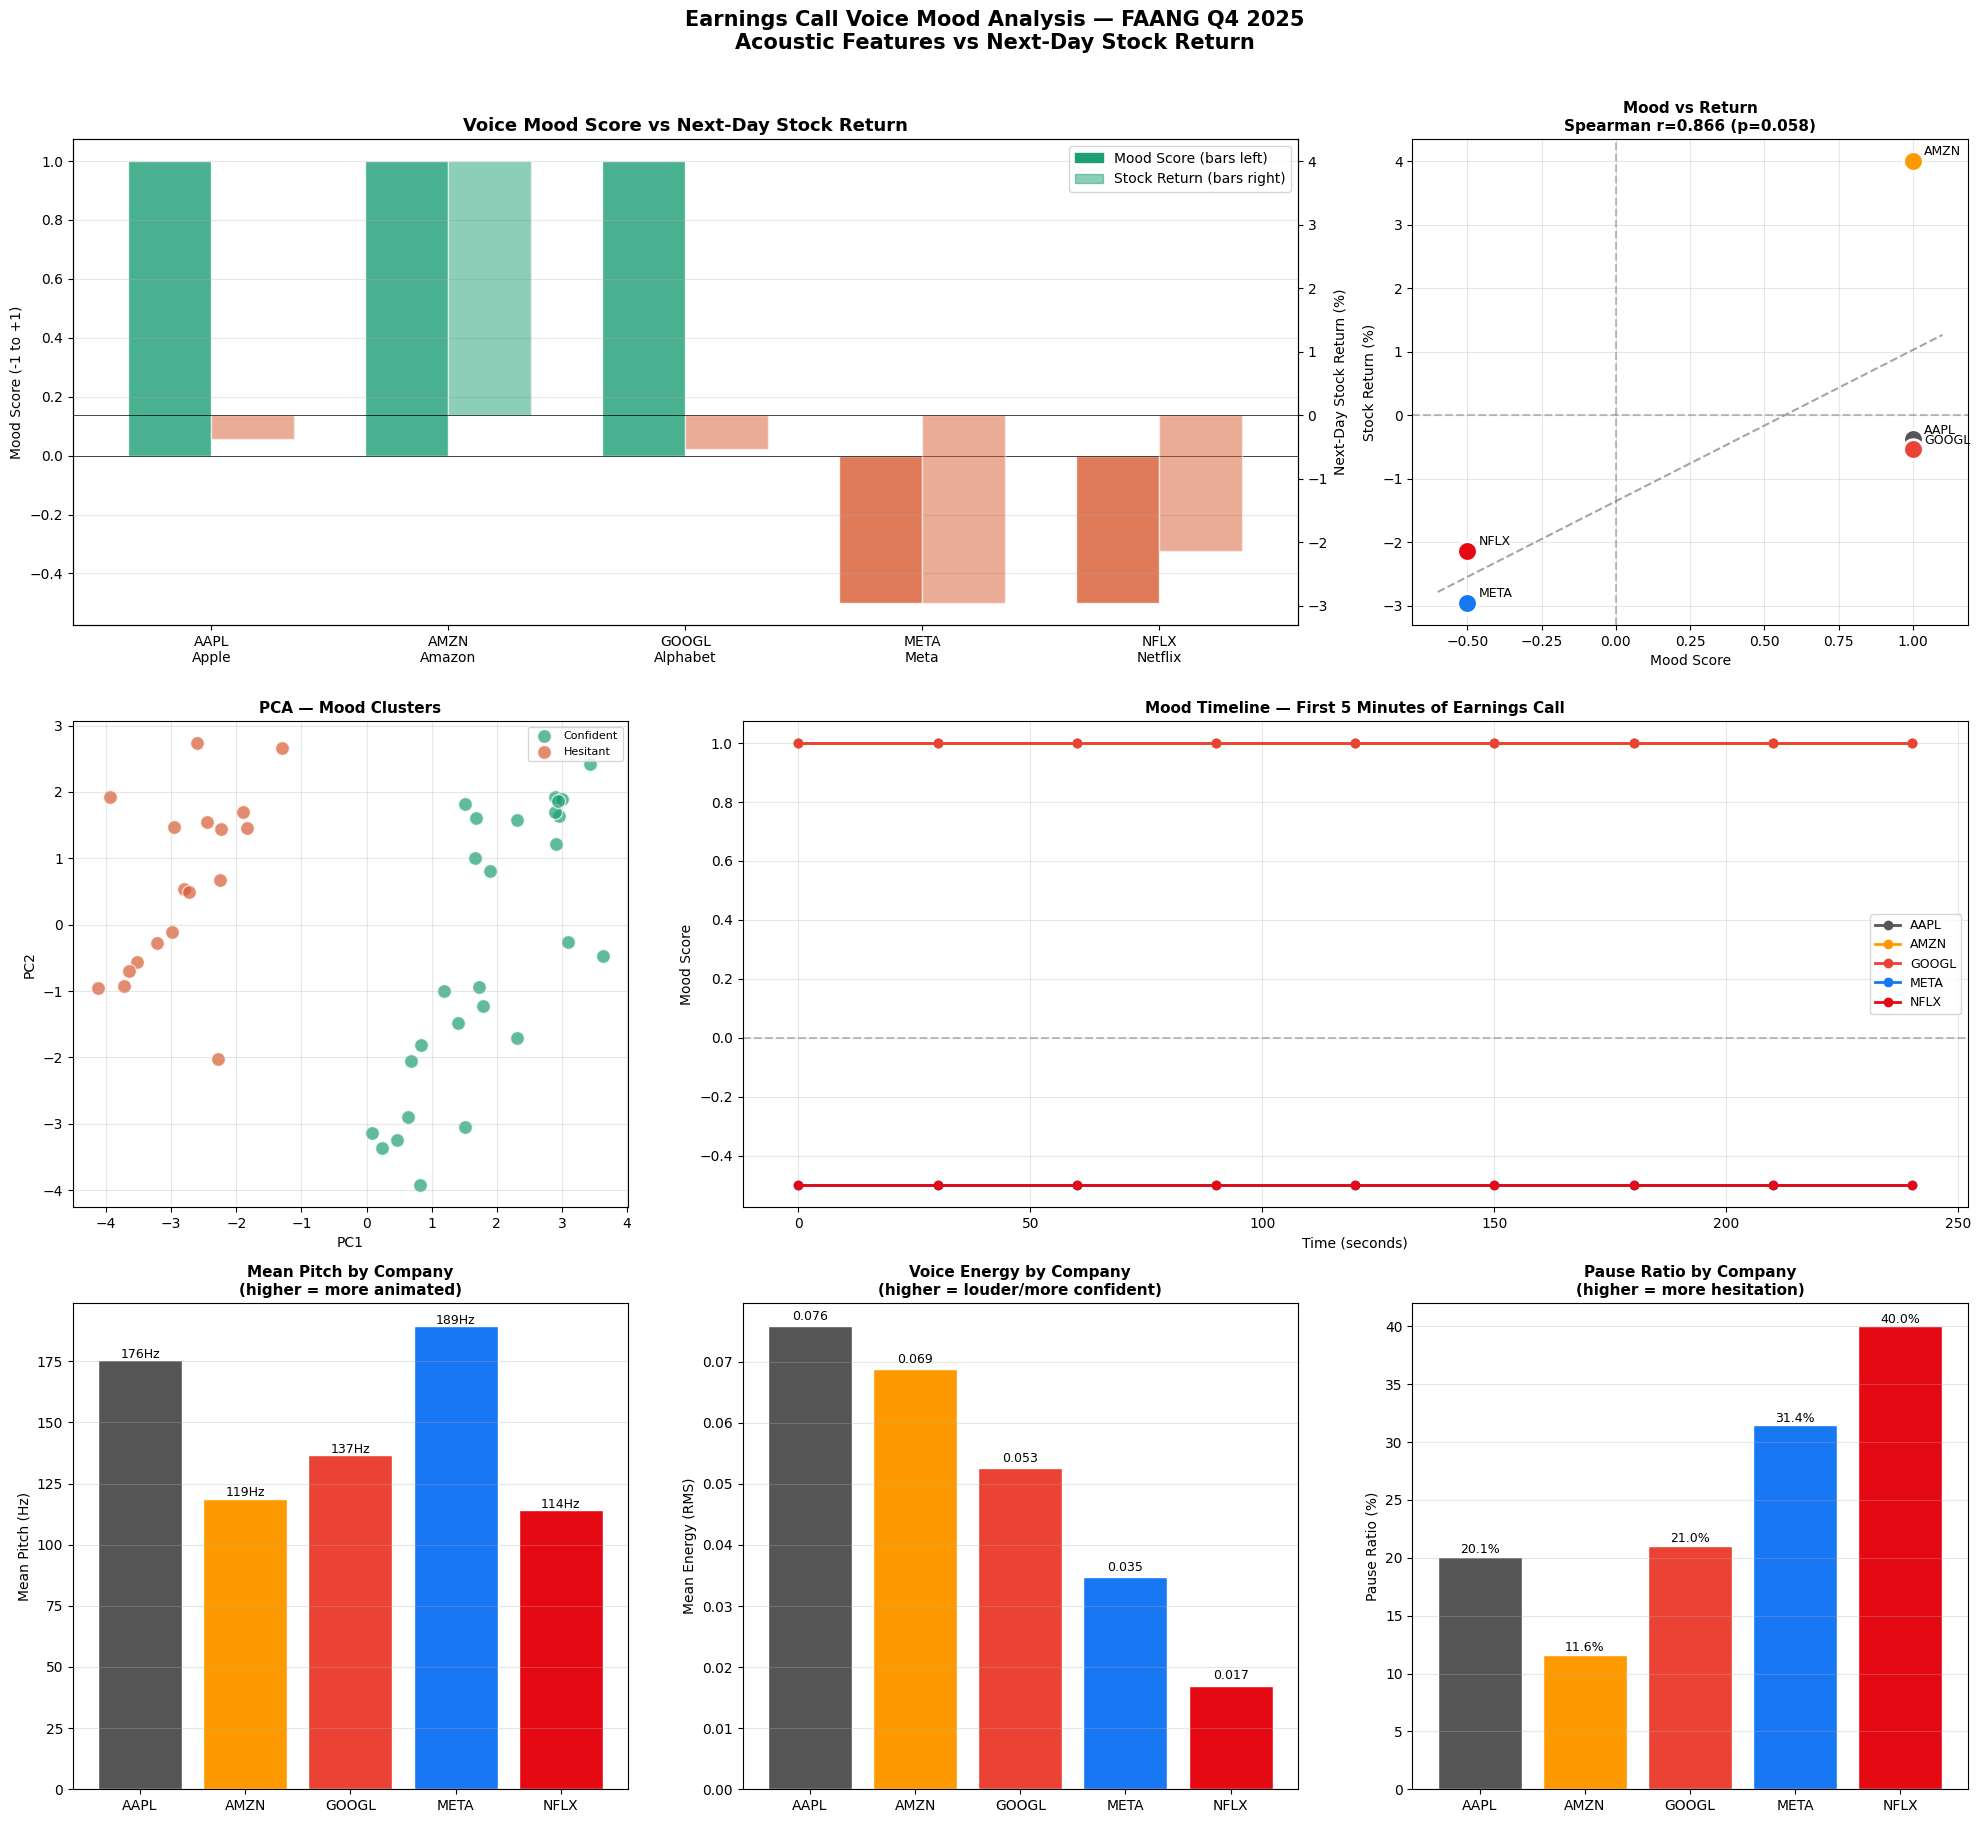


── Final Summary ──
   Companies analyzed : 5
   Segments per company: 9 (30s each = 4.5 min)
   Spearman correlation: +0.8660 (mood vs stock return)

   Confident speakers  : AAPL, AMZN, GOOGL
   Hesitant speakers   : META, NFLX

✅ Saved: /content/drive/MyDrive/earnings_mood/mood_dashboard.png
✅ Block 4 complete


In [7]:
# Block 4: Full visualization dashboard — mood timeline per company,
# PCA cluster plot, mood vs stock return correlation,
# and acoustic feature comparison across companies.

import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

DRIVE_PATH    = '/content/drive/MyDrive/earnings_mood'
ANALYSIS_FILE = f'{DRIVE_PATH}/mood_analysis.pkl'

with open(ANALYSIS_FILE, 'rb') as f:
    saved = pickle.load(f)

df_all         = saved['df_all']
company_mood   = saved['company_mood']
stock_reactions = saved['stock_reactions']
X_pca          = saved['X_pca']

print("✅ Data loaded")

MOOD_COLORS = {
    'Confident': '#1D9E75',
    'Energetic': '#378ADD',
    'Hesitant' : '#D85A30',
    'Stressed' : '#7F77DD'
}

COMPANY_COLORS = {
    'AAPL' : '#555555',
    'META' : '#1877F2',
    'GOOGL': '#EA4335',
    'AMZN' : '#FF9900',
    'NFLX' : '#E50914'
}

# ── 1. Dashboard ──────────────────────────────────────────────
fig = plt.figure(figsize=(20, 18))
gs  = gridspec.GridSpec(3, 3, figure=fig)

# Plot 1: Mood score vs stock return
ax1 = fig.add_subplot(gs[0, :2])
tickers = company_mood.index.tolist()
x       = np.arange(len(tickers))
width   = 0.35

mood_vals   = company_mood['mood_score'].values
return_vals = company_mood['stock_return'].values * 100

bars1 = ax1.bar(x - width/2, mood_vals, width,
                label='Mood Score', color=[
                    '#1D9E75' if v > 0 else '#D85A30' for v in mood_vals
                ], alpha=0.8, edgecolor='white')
ax2_twin = ax1.twinx()
bars2 = ax2_twin.bar(x + width/2, return_vals, width,
                     label='Stock Return (%)',
                     color=['#1D9E75' if v > 0 else '#D85A30' for v in return_vals],
                     alpha=0.5, edgecolor='white')

ax1.set_xticks(x)
ax1.set_xticklabels([f"{t}\n{company_mood.loc[t,'company'] if 'company' in company_mood.columns else t}"
                     for t in tickers])
ax1.set_ylabel('Mood Score (-1 to +1)')
ax2_twin.set_ylabel('Next-Day Stock Return (%)')
ax1.set_title('Voice Mood Score vs Next-Day Stock Return',
              fontsize=13, fontweight='bold')
ax1.axhline(y=0, color='black', linewidth=0.5)
ax2_twin.axhline(y=0, color='black', linewidth=0.5)

lines1 = mpatches.Patch(color='#1D9E75', label='Mood Score (bars left)')
lines2 = mpatches.Patch(color='#1D9E75', alpha=0.5, label='Stock Return (bars right)')
ax1.legend(handles=[lines1, lines2], loc='upper right')
ax1.grid(alpha=0.3, axis='y')

# Plot 2: Correlation scatter
ax3 = fig.add_subplot(gs[0, 2])
for ticker in tickers:
    row = company_mood.loc[ticker]
    color = COMPANY_COLORS.get(ticker, '#888780')
    ax3.scatter(row['mood_score'], row['stock_return'] * 100,
                s=200, color=color, zorder=5, edgecolors='white', linewidth=2)
    ax3.annotate(ticker, (row['mood_score'], row['stock_return'] * 100),
                 textcoords='offset points', xytext=(8, 4), fontsize=9)

# Trend line
valid = company_mood.dropna(subset=['stock_return'])
z     = np.polyfit(valid['mood_score'], valid['stock_return'] * 100, 1)
p     = np.poly1d(z)
x_line = np.linspace(valid['mood_score'].min() - 0.1, valid['mood_score'].max() + 0.1, 100)
ax3.plot(x_line, p(x_line), '--', color='gray', linewidth=1.5, alpha=0.7)

from scipy.stats import spearmanr
sr, sp = spearmanr(valid['mood_score'], valid['stock_return'])
ax3.set_xlabel('Mood Score')
ax3.set_ylabel('Stock Return (%)')
ax3.set_title(f'Mood vs Return\nSpearman r={sr:.3f} (p={sp:.3f})',
              fontsize=11, fontweight='bold')
ax3.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax3.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax3.grid(alpha=0.3)

# Plot 3: PCA cluster plot
ax4 = fig.add_subplot(gs[1, 0])
for mood, color in MOOD_COLORS.items():
    mask = df_all['mood'] == mood
    if mask.sum() > 0:
        ax4.scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=color, label=mood, alpha=0.7, s=100, edgecolors='white')
ax4.set_xlabel('PC1')
ax4.set_ylabel('PC2')
ax4.set_title('PCA — Mood Clusters', fontsize=11, fontweight='bold')
ax4.legend(fontsize=8)
ax4.grid(alpha=0.3)

# Plot 4: Mood timeline per company
ax5 = fig.add_subplot(gs[1, 1:])
for ticker in tickers:
    df_co  = df_all[df_all['ticker'] == ticker].sort_values('timestamp')
    times  = df_co['timestamp'].values
    scores = df_co['mood_score'].values
    color  = COMPANY_COLORS.get(ticker, '#888780')
    ax5.plot(times, scores, marker='o', label=ticker,
             color=color, linewidth=2, markersize=6)

ax5.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax5.set_xlabel('Time (seconds)')
ax5.set_ylabel('Mood Score')
ax5.set_title('Mood Timeline — First 5 Minutes of Earnings Call',
              fontsize=11, fontweight='bold')
ax5.legend(fontsize=9)
ax5.grid(alpha=0.3)

# Plot 5: Acoustic features comparison
ax6 = fig.add_subplot(gs[2, 0])
pitch_vals = [df_all[df_all['ticker']==t]['mean_pitch'].mean() for t in tickers]
colors_bar = [COMPANY_COLORS.get(t, '#888') for t in tickers]
bars = ax6.bar(tickers, pitch_vals, color=colors_bar, edgecolor='white')
for bar, val in zip(bars, pitch_vals):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.0f}Hz', ha='center', fontsize=9)
ax6.set_ylabel('Mean Pitch (Hz)')
ax6.set_title('Mean Pitch by Company\n(higher = more animated)',
              fontsize=11, fontweight='bold')
ax6.grid(alpha=0.3, axis='y')

# Plot 6: Energy comparison
ax7 = fig.add_subplot(gs[2, 1])
energy_vals = [df_all[df_all['ticker']==t]['mean_energy'].mean() for t in tickers]
bars = ax7.bar(tickers, energy_vals, color=colors_bar, edgecolor='white')
for bar, val in zip(bars, energy_vals):
    ax7.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{val:.3f}', ha='center', fontsize=9)
ax7.set_ylabel('Mean Energy (RMS)')
ax7.set_title('Voice Energy by Company\n(higher = louder/more confident)',
              fontsize=11, fontweight='bold')
ax7.grid(alpha=0.3, axis='y')

# Plot 7: Pause ratio comparison
ax8 = fig.add_subplot(gs[2, 2])
pause_vals = [df_all[df_all['ticker']==t]['pause_ratio'].mean() * 100 for t in tickers]
bars = ax8.bar(tickers, pause_vals, color=colors_bar, edgecolor='white')
for bar, val in zip(bars, pause_vals):
    ax8.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontsize=9)
ax8.set_ylabel('Pause Ratio (%)')
ax8.set_title('Pause Ratio by Company\n(higher = more hesitation)',
              fontsize=11, fontweight='bold')
ax8.grid(alpha=0.3, axis='y')

plt.suptitle('Earnings Call Voice Mood Analysis — FAANG Q4 2025\nAcoustic Features vs Next-Day Stock Return',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/mood_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n── Final Summary ──")
print(f"   Companies analyzed : {df_all['ticker'].nunique()}")
print(f"   Segments per company: 9 (30s each = 4.5 min)")
print(f"   Spearman correlation: {sr:+.4f} (mood vs stock return)")
print(f"\n   Confident speakers  : {', '.join(company_mood[company_mood['mood_score']>0].index.tolist())}")
print(f"   Hesitant speakers   : {', '.join(company_mood[company_mood['mood_score']<0].index.tolist())}")
print(f"\n✅ Saved: {DRIVE_PATH}/mood_dashboard.png")
print("✅ Block 4 complete")